<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/Logo_EICT_horizontal_ESPANOL%20(1).png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Algoritmo de Grover   </p> listas no estructuradas </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Tesis</p></tp>
            <tp><p style="font-size:115%;text-align:center">Maestría ICT 2025-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Stiven Paloma Alarcon</p></tp>
        </td>
    </tr>
</table>



# <FONT SIZE=5 COLOR="white"> **Aplicación del Algoritmo de Grover en búsquedas no estructuradas: análisis y comparación de la eficiencia de algoritmos de búsqueda con algoritmos cuánticos.** </FONT>

Las búsquedas en bases de datos no estructuradas o listas no ordenadas son un desafío esencial en la teoría de la computación, debido a la ausencia de un orden que permita aprovechar técnicas de optimización clásicas. En este tipo de problemas, la localización de un elemento que cumple una propiedad específica requiere, en el caso clásico, un análisis exhaustivo de los N elementos presentes en la base de datos, lo que implica un costo computacional promedio de O(N). Este límite se mantiene incluso con enfoques avanzados descritos en trabajos fundamentales de autores como Knuth (1998), quien en The Art of Computer Programming analiza a profundidad las técnicas de búsqueda lineal y sus limitaciones en ausencia de estructura (Knuth, 1998). De manera similar, Cormen, Leiserson, Rivest y Stein (2009) subrayan en Introduction to Algorithms que las búsquedas no estructuradas no pueden beneficiarse de optimizaciones derivadas de estructuras jerárquicas, como árboles de búsqueda o tablas hash, destacando que el rendimiento está limitado por la necesidad de inspeccionar cada elemento de manera secuencial. Por otro lado, Sedgewick (2011) y Wirth (1976) abordan estrategias relacionadas con la eficiencia en algoritmos de búsqueda, pero recalcan que los avances en estructuras de datos no eliminan la barrera inherente de O(N) para problemas sin orden. En este contexto, la computación cuántica ofrece una solución innovadora al problema de búsquedas no estructuradas. El Algoritmo de Grover, introducido en 1996, reduce el tiempo de búsqueda a O(√ N), logrando una aceleración cuadrática en comparación con los algoritmos clásicos. Esto se consigue mediante transformaciones iterativas basadas en la superposición cuántica y la interferencia constructiva, lo que amplifica la probabilidad del estado objetivo y atenúa las demás posibilidades (Grover, 1996). Este avance, sin embargo, enfrenta retos en su implementación práctica, como la preservación de la coherencia cuántica, el diseño de oráculos específicos para cada problema y la necesidad de puertas cuánticas de alta fidelidad. Este proyecto se centra en la implementación del Algoritmo Cuántico de Grover, donde se explorará en simulaciones de computación cuántica con apoyo del lenguaje Qiskit, contribuyendo a una comprensión más profunda de cómo estas técnicas pueden resolver problemas fundamentales de búsqueda con mayor eficiencia. El análisis combinado de estas limitaciones clásicas y los avances cuánticos pone de manifiesto el potencial transformador del Algoritmo de Grover para problemas de búsqueda en bases de datos no estructuradas, aportando una perspectiva novedosa que supera los enfoques tradicionales estudiados por autores como Knuth, Cormen et al., Sedgewick y Wirth.




In [1]:
import math
from typing import List, Tuple
import numpy as np
import random
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import MCMT
from qiskit.visualization import plot_histogram

from qiskit.circuit.library import MCXGate
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.primitives import Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from IPython.display import display

In [2]:
def ceil_log2(N: int) -> int:
    return math.ceil(math.log2(N))

def int_to_bits(x: int, n: int) -> List[int]:
    b = [(x >> i) & 1 for i in range(n)]
    return list(reversed(b)) 

def k_optimal(N: int, M: int = 1, rule: str = "floor") -> int:
    val = (math.pi/4.0) * math.sqrt(N/M)
    return math.floor(val) if rule == "floor" else int(round(val))

def oracle_equals(target_bits: List[int]) -> QuantumCircuit:
    n = len(target_bits)
    qc = QuantumCircuit(n + 1, name='Oracle=target')
   
    qc.mcx(list(range(n)), n, mode='noancilla') 

    return qc

In [3]:
def diffuser(n: int) -> QuantumCircuit:
    df = QuantumCircuit(n, name='Diffuser')
    if n == 1:
        df.z(0)
    else:
        df.mcx(list(range(n-1)), n-1, mode='noancilla')
    return df

def build_grover_circuit(n: int, target_value: int, iters: int) -> QuantumCircuit:
    target_bits = int_to_bits(target_value, n)
    O = oracle_equals(target_bits)
    D = diffuser(n)

    qc = QuantumCircuit(n + 1, n, name=f'Grover_n{n}_k{iters}')
    # Superposicion en la que inicio
    for i in range(n): qc.h(i)
    qc.x(n); qc.h(n)

    for _ in range(iters):
        qc.append(O.to_gate(), range(n+1))
        qc.append(D.to_gate(), range(n))

    qc.measure(range(n), range(n))
    return qc

def run_simulation(qc: QuantumCircuit, shots: int = 4096, optimization_level: int = 3):
    backend = Aer.get_backend("aer_simulator")  # este es el simulador que uso para correr el circuito
    tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
    tqc = tqc.copy()
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()
    return counts

def bitstring_to_int(s: str) -> int:
    return int(s, 2)

In [4]:
if __name__ == "__main__":
    # parametros para N=20M
    N_real = 20_000_000
    target_real = 1_234_323
    n_real = ceil_log2(N_real)  
    k_real_floor = k_optimal(N_real, M=1, rule="floor")   
    k_real_round = k_optimal(N_real, M=1, rule="round") 

    print(f"[Real] N={N_real}, n={n_real}, k_floor={k_real_floor}, k_round={k_real_round}")

    n_demo = 16
    N_demo = 2**n_demo
    # Mapeador simple para la demostracion o ejemplo
    target_demo = target_real % N_demo
    k_demo = k_optimal(N_demo, M=1, rule="floor")
    print(f"[Demo] N={N_demo}, n={n_demo}, target={target_demo}, k_demo={k_demo}")

    k_demo_run = min(k_demo, 50)
    qc_demo = build_grover_circuit(n_demo, target_demo, k_demo_run)
    counts = run_simulation(qc_demo, shots=4096, optimization_level=3)

    # Procesa los resultados 
    top = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:5]
    print("\n[Demo] Top-5 bitstrings (bitstring -> int : counts):")
    for s, c in top:
        print(f"{s} -> {bitstring_to_int(s)} : {c}")

    # Se construye el circuito para poder correr el ejercicio, no olvidar que hay realizar un proceso
    k_20M_run = 20 
    qc_20M = build_grover_circuit(n_real, target_real, k_20M_run)
    print(f"\nQubits={qc_20M.num_qubits}")



[Real] N=20000000, n=25, k_floor=3512, k_round=3512
[Demo] N=65536, n=16, target=54675, k_demo=201

[Demo] Top-5 bitstrings (bitstring -> int : counts):
0111101101101111 -> 31599 : 2
0101000111010110 -> 20950 : 2
0111101010110010 -> 31410 : 2
1010101000001011 -> 43531 : 2
0000010110001010 -> 1418 : 2

Qubits=26


EJERCICIO PROPUESTO COMO INDICE EL NÚMERO OBJETIVO

In [6]:
N = 20_000_000
elemento_buscado = 1_234_323

# Calculamos el número de cúbits necesarios
n_qubits = math.ceil(math.log2(N))

print(f"Tamaño de la lista (N): {N}")
print(f"Número de cúbits requeridos (n): {n_qubits}")

indice_buscado = random.randint(0, N - 1)
marcado_binario = format(indice_buscado, f'0{n_qubits}b')

print(f"Elemento que tiene que buscar buscar: {elemento_buscado}")
print(f"Lo hemos colocado en el índice: {indice_buscado}")
print(f"La representación binaria de este índice es: {marcado_binario}")

Tamaño de la lista (N): 20000000
Número de cúbits requeridos (n): 25
Elemento que tiene que buscar buscar: 1234323
Lo hemos colocado en el índice: 6059075
La representación binaria de este índice es: 0010111000111010001000011


EJEMPLO SENCILLO DE LA LÓGICA DEL ORACULO

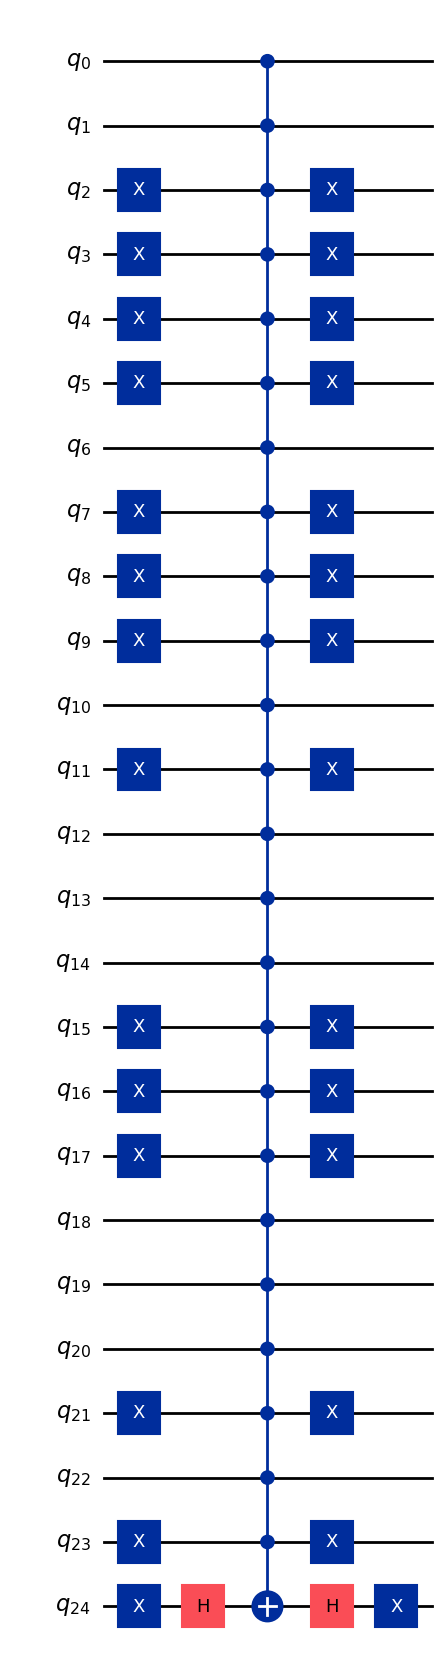

In [7]:

oracle = QuantumCircuit(n_qubits, name='oracle')

for i, bit in enumerate(reversed(marcado_binario)):
    if bit == '0':
        oracle.x(i)

oracle.h(n_qubits - 1)
oracle.mcx(list(range(n_qubits - 1)), n_qubits - 1)
oracle.h(n_qubits - 1)

for i, bit in enumerate(reversed(marcado_binario)):
    if bit == '0':
        oracle.x(i)

oracle.draw('mpl')

Creación del difusor

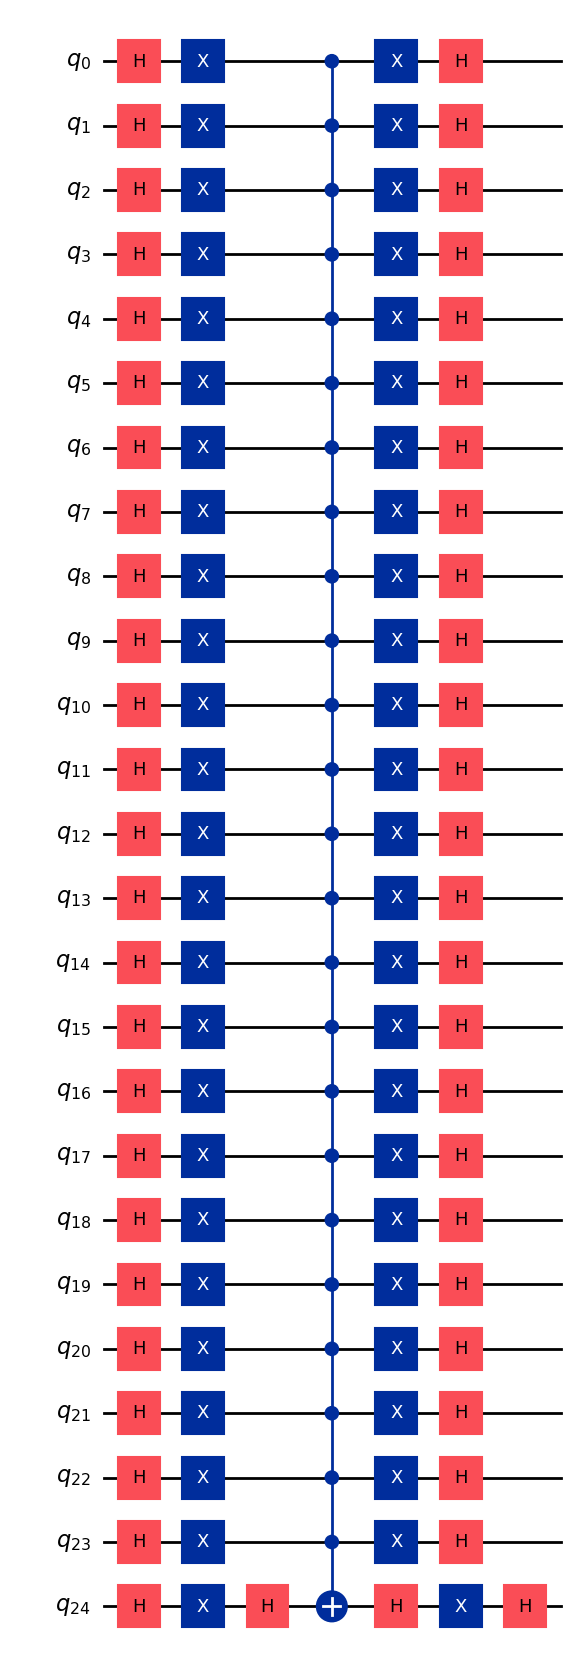

In [8]:
# Difusor
diffusion = QuantumCircuit(n_qubits, name='diffusion')

# superposición inicial
diffusion.h(range(n_qubits))

# compuerta x
diffusion.x(range(n_qubits))

# multicontrol z
diffusion.h(n_qubits - 1)
diffusion.mcx(list(range(n_qubits - 1)), n_qubits - 1)
diffusion.h(n_qubits - 1)

# compuertas x a todos 
diffusion.x(range(n_qubits))

diffusion.h(range(n_qubits))

diffusion.draw('mpl')

ALGORITO COMPLETO, EJERCICIO DE PRUEBA

In [9]:
# CALCULAR EL NÙMERO DE ITERACIONES
iteraciones = int(math.pi / 4 * math.sqrt(N))
print(f'Número óptimo de iteraciones de Grover: {iteraciones}')

qc = QuantumCircuit(n_qubits)

qc.h(range(n_qubits))

for _ in range(iteraciones):
    qc.compose(oracle, inplace=True)
    qc.compose(diffusion, inplace=True)

qc.measure_all()

print("\\ Inicio")

backend = Aer.get_backend('aer_simulator')

qc_transpilado = transpile(qc, backend)

job = backend.run(qc_transpilado, shots=1, memory=True)

# Obtenemos los resultados
resultado = job.result()
medicion_binaria = resultado.get_memory()[0]
medicion_decimal = int(medicion_binaria, 2)

print("\\Completado")
print(f"El estado medido es: {medicion_binaria}")
print(f"Que corresponde al índice: {medicion_decimal}")

if medicion_decimal == indice_buscado:
    print(f"Se encontro el  {indice_buscado}")
else:
    print(f"No se encontro {medicion_decimal} el {indice_buscado}.")

Número óptimo de iteraciones de Grover: 3512
\ Inicio
\Completado
El estado medido es: 0010111000111010001000011
Que corresponde al índice: 6059075
Se encontro el  6059075


EJEMPLO VISUAL DEL COMPORTAMIENTO DEL ALGORITMO DE GROVER

Generando gráfica para: n=10, N=1024, target=318
Iniciando...
  Iteraciones k=  1 -> Probabilidad de éxito = 0.0010
  Iteraciones k= 10 -> Probabilidad de éxito = 0.0006
  Iteraciones k= 20 -> Probabilidad de éxito = 0.0001
  Iteraciones k= 30 -> Probabilidad de éxito = 0.0001
  Iteraciones k= 40 -> Probabilidad de éxito = 0.0007

Simulación finalizada


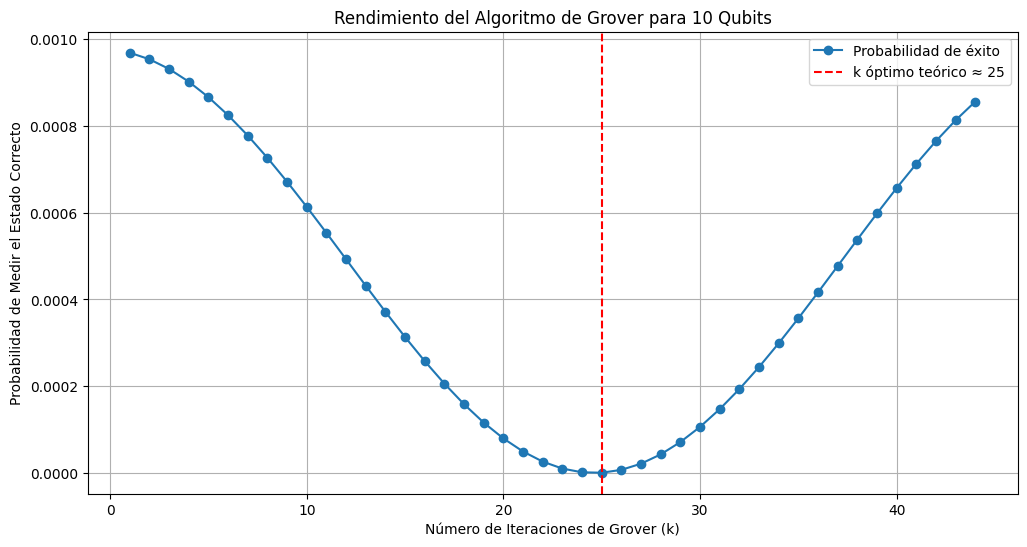

In [10]:
def k_optimal(N: int, M: int = 1, rule: str = "round") -> int:
    if N == 0: return 0
    val = (math.pi / 4.0) * math.sqrt(N / M)
    return math.floor(val) if rule == "floor" else int(round(val))

def int_to_bits(x: int, n: int) -> List[int]:
    b = [(x >> i) & 1 for i in range(n)]
    return list(reversed(b))

def oracle_equals(target_bits: List[int]) -> QuantumCircuit:
    n = len(target_bits)
    qc = QuantumCircuit(n + 1, name='Oracle')
    
    for i, b in enumerate(target_bits):
        if b == 0:
            qc.x(i)
            
    qc.mcx(list(range(n)), n, mode='noancilla')
    
    for i, b in enumerate(target_bits):
        if b == 0:
            qc.x(i)
            
    return qc

def diffuser(n: int) -> QuantumCircuit:
    df = QuantumCircuit(n, name='Difusor')
    df.h(range(n))
    df.x(range(n))
    df.h(n - 1)
    df.mcx(list(range(n - 1)), n - 1, mode='noancilla')
    df.h(n - 1)
    df.x(range(n))
    df.h(range(n))
    return df

def get_success_probability(qc, target_value):
    backend = AerSimulator(method='statevector')
    result = backend.run(qc).result()
    statevector = result.get_statevector()
    prob = 0
    num_computational_states = 2**qc.num_qubits
    for i in range(num_computational_states):
        if (i >> 1) == target_value:
             prob += np.abs(statevector[i])**2
    return prob

n_grafica = 10
N_grafica = 2**n_grafica
target_grafica = np.random.randint(0, N_grafica)
print(f"Generando gráfica para: n={n_grafica}, N={N_grafica}, target={target_grafica}")

k_optimo = k_optimal(N_grafica, rule="round")
iteraciones_a_probar = range(1, int(1.8 * k_optimo))
probabilidades = []

target_bits_grafica = int_to_bits(target_grafica, n_grafica)
O_grafica = oracle_equals(target_bits_grafica)
D_grafica = diffuser(n_grafica)

print("Iniciando...")
for k in iteraciones_a_probar:
    qc_k = QuantumCircuit(n_grafica + 1)

    qc_k.h(range(n_grafica))
    qc_k.x(n_grafica)
    qc_k.h(n_grafica)
    
    for _ in range(k):
        qc_k.compose(O_grafica, inplace=True)
        qc_k.compose(D_grafica, qubits=range(n_grafica), inplace=True)
    qc_k.save_statevector()
    
    prob = get_success_probability(qc_k, target_grafica)
    probabilidades.append(prob)
    
    if k % 10 == 0 or k == 1:
        print(f"  Iteraciones k={k:3d} -> Probabilidad de éxito = {prob:.4f}")

print("\nSimulación finalizada")
plt.figure(figsize=(12, 6))
plt.plot(iteraciones_a_probar, probabilidades, 'o-', label='Probabilidad de éxito')
plt.axvline(k_optimo, color='r', linestyle='--', label=f'k óptimo teórico ≈ {k_optimo}')
plt.xlabel("Número de Iteraciones de Grover (k)")
plt.ylabel("Probabilidad de Medir el Estado Correcto")
plt.title(f"Rendimiento del Algoritmo de Grover para {n_grafica} Qubits")
plt.grid(True)
plt.legend()
plt.show()

Visualizando para n=6, N=64, target=21, k_optimo=6


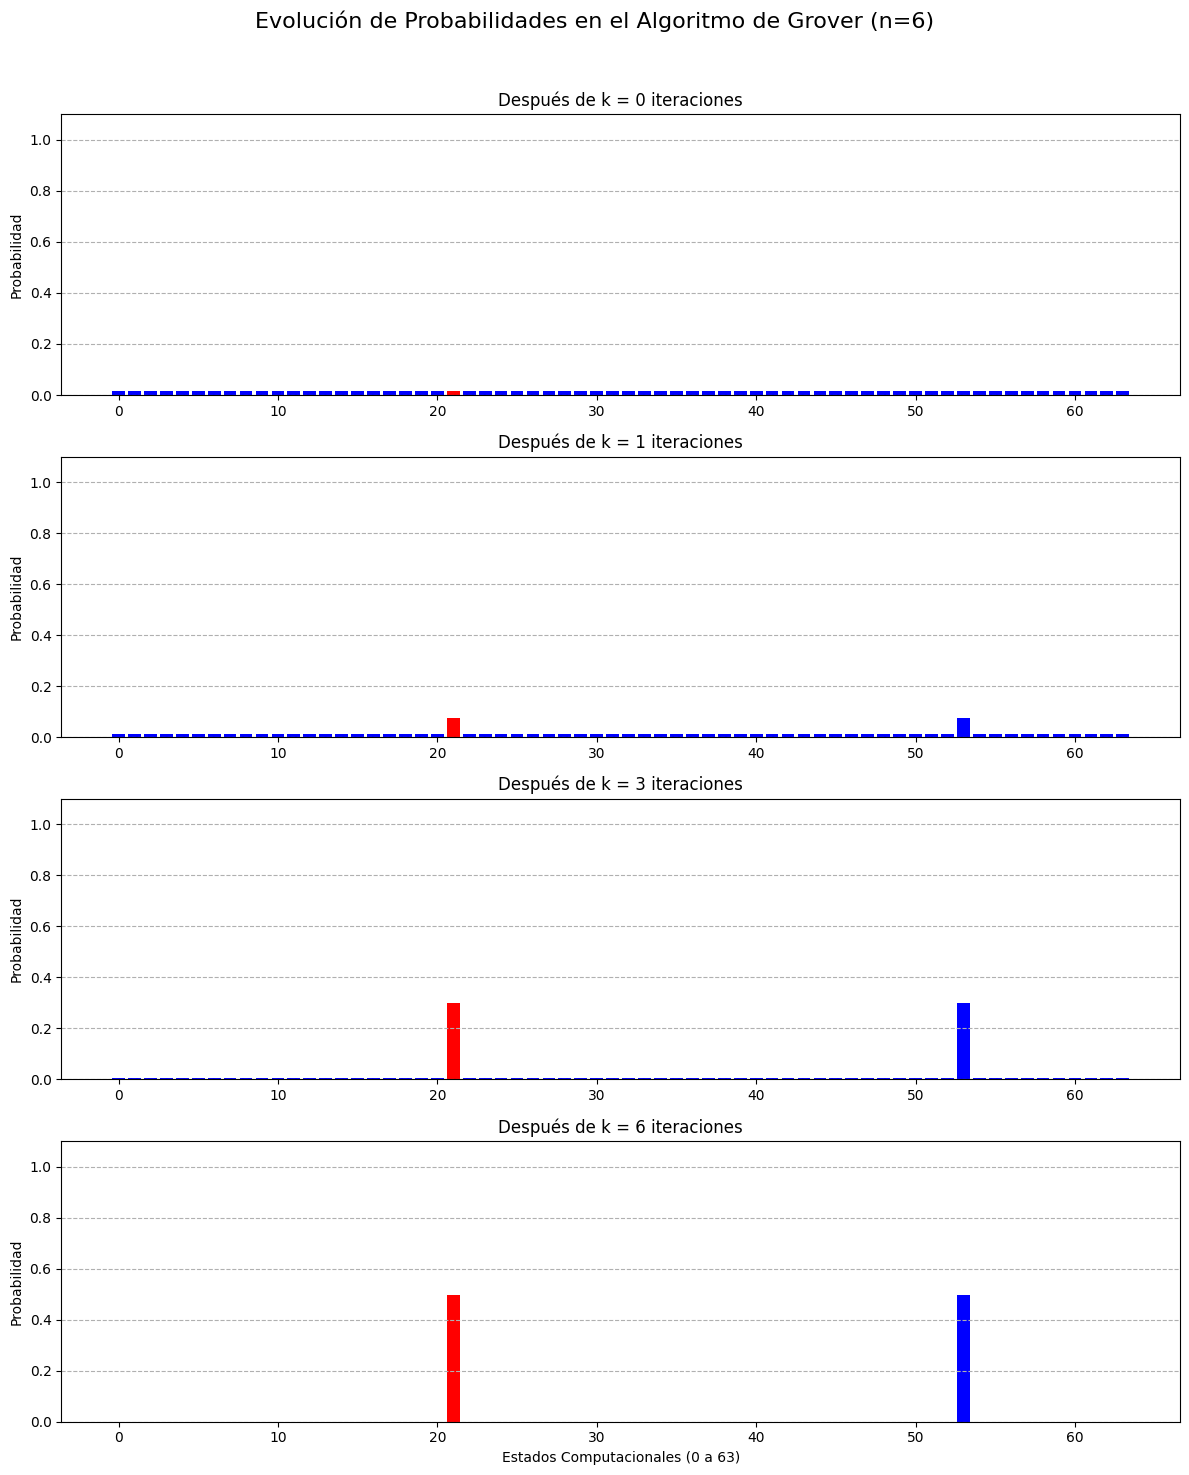

In [ ]:

n_viz = 6
N_viz = 2**n_viz
target_viz = np.random.randint(0, N_viz)
k_optimo_viz = int(round((np.pi / 4) * np.sqrt(N_viz)))
iteraciones_a_visualizar = [0, 1, k_optimo_viz // 2, k_optimo_viz]

print(f"Visualizando para n={n_viz}, N={N_viz}, target={target_viz}, k_optimo={k_optimo_viz}")

target_bits_viz = int_to_bits(target_viz, n_viz)
O_viz = oracle_equals(target_bits_viz)
D_viz = diffuser(n_viz)

fig, axs = plt.subplots(len(iteraciones_a_visualizar), 1, figsize=(12, 15))
fig.suptitle(f'Evolución de Probabilidades en el Algoritmo de Grover (n={n_viz})', fontsize=16)

for i, k in enumerate(iteraciones_a_visualizar):
    qc = QuantumCircuit(n_viz + 1)
    qc.h(range(n_viz))
    qc.x(n_viz); qc.h(n_viz)

    for _ in range(k):
        qc.compose(O_viz, inplace=True)
        qc.compose(D_viz, qubits=range(n_viz), inplace=True)

    qc.save_statevector()

    backend = AerSimulator(method='statevector')
    result = backend.run(qc).result()
    statevector = result.get_statevector()

    probs = np.zeros(N_viz)
    for state_idx in range(2**(n_viz+1)):
        work_qubit_idx = state_idx >> 1
        probs[work_qubit_idx] += np.abs(statevector[state_idx])**2
        
    # Graficar
    ax = axs[i]
    colors = ['r' if j == target_viz else 'b' for j in range(N_viz)]
    ax.bar(range(N_viz), probs, color=colors)
    ax.set_ylabel('Probabilidad')
    ax.set_title(f'Después de k = {k} iteraciones')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--')

plt.xlabel('Estados Computacionales (0 a 63)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Mostrando el diagrama de alto nivel del circuito de Grover:


c:\Users\USUARIO\Desktop\STEVEN ESCRITORIO\UROSARIO\3er SEMESTRE\Tesis\AlgoritmoGR\.tesis\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: c:\Users\USUARIO\Desktop\STEVEN ESCRITORIO\UROSARIO\3er SEMESTRE\Tesis\AlgoritmoGR\.tesis\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


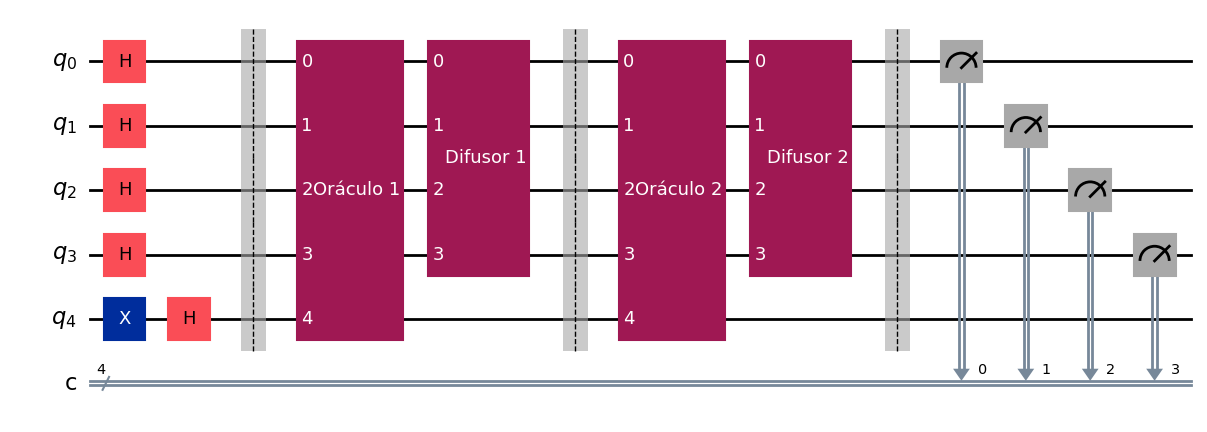

In [ ]:
from qiskit import QuantumCircuit
from IPython.display import display

n_viz = 4
target_viz = 7
k_viz = 2      

target_bits_viz = int_to_bits(target_viz, n_viz)
oracle_viz = oracle_equals(target_bits_viz)
diffuser_viz = diffuser(n_viz)

qc_high_level = QuantumCircuit(n_viz + 1, n_viz, name="Grover")


qc_high_level.h(range(n_viz))
qc_high_level.x(n_viz)
qc_high_level.h(n_viz)
qc_high_level.barrier()

for i in range(k_viz):
    oracle_gate = oracle_viz.to_gate(label=f'Oráculo {i+1}')
    qc_high_level.append(oracle_gate, range(n_viz + 1))
    diffuser_gate = diffuser_viz.to_gate(label=f'Difusor {i+1}')
    qc_high_level.append(diffuser_gate, range(n_viz))
    
    qc_high_level.barrier()

qc_high_level.measure(range(n_viz), range(n_viz))

print("Circuito de Grover:")
display(qc_high_level.draw('mpl', style='iqx'))

Diagrama detallado del circuito de Grover para k=2:


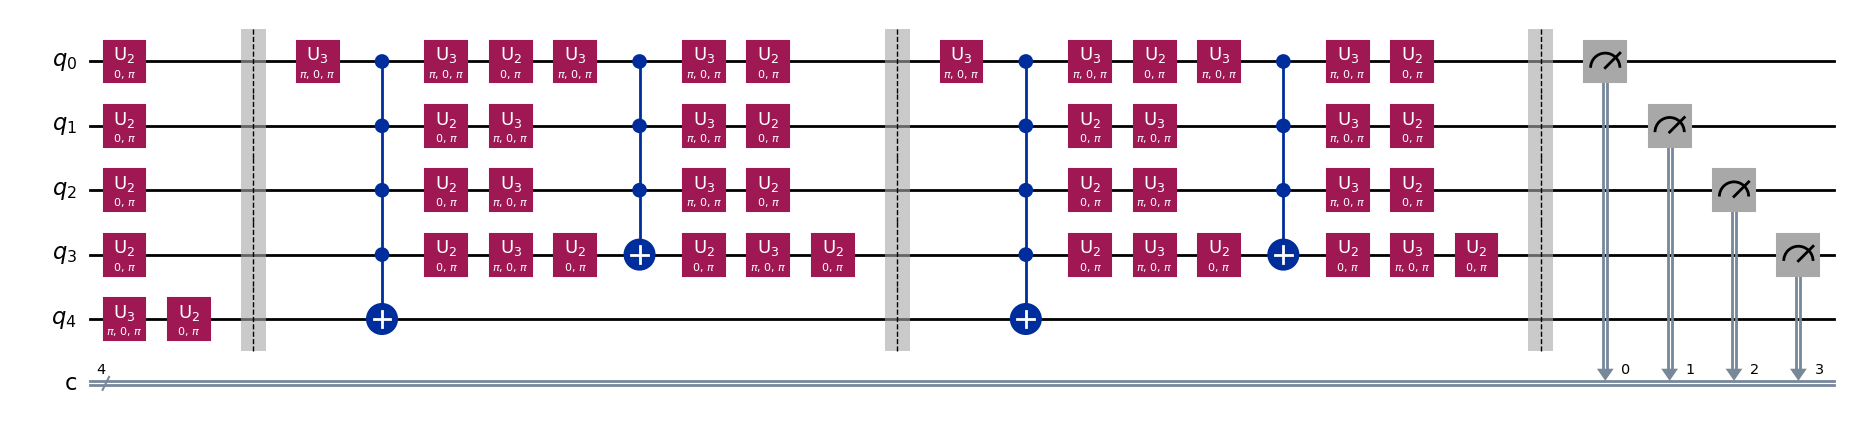

In [ ]:

n_viz = 4
target_viz = 7 
k_viz = 2   

target_bits_viz = int_to_bits(target_viz, n_viz)
oracle_viz = oracle_equals(target_bits_viz)
diffuser_viz = diffuser(n_viz)

qc_high_level = QuantumCircuit(n_viz + 1, n_viz)
qc_high_level.h(range(n_viz))
qc_high_level.x(n_viz); qc_high_level.h(n_viz)
qc_high_level.barrier()

for _ in range(k_viz):
    qc_high_level.compose(oracle_viz, inplace=True)
    qc_high_level.compose(diffuser_viz, qubits=range(n_viz), inplace=True)
    qc_high_level.barrier()

qc_high_level.measure(range(n_viz), range(n_viz))

qc_detailed = qc_high_level.decompose()

print("Diagrama detallado del circuito de Grover para k=2:")
display(qc_detailed.draw('mpl', style='iqx', fold=-1))